# **Applied Machine Learning Lab-(MCSE630P)**

**Assignment 3-Decision Tree**

**Name:** Shrihariharan S [24MCS1058]

**Decision Tree :**

* Taken decision tree dataset from Kaggle https://www.kaggle.com/competitions/problem1-bank-customer-churn-prediction
* Converting the ordinal and nominal data in the dataset to numerical data using one hot encoding and Lable encoding
* scaling the larger values to smaller values using standard scalar for Normalization
* Found outliers in dataset using boxblot and capped it using IQR method
* Found the corelation between dependent and independent variable using heat map
* split the dataset into training and test data
* trained the model DecisionTreeClassifier using training data and predicted the value of y_pred using test data.

* compared the actual y_test value with predicted y_pred value and found the accuracy score
* plotted the decision tree of max depth 5.
* checked for the accurracy of decision tree using various max depth values.
* checked accuracy of the dataset with logistic vs Decision Tree
* Trained the model by changing the different parameters and predicted the accuracy

In [ ]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [ ]:
#connection with kaggle
! pip install -q kaggle

In [ ]:
! mkdir ~/.kaggle

In [ ]:
#attaching kaggle.json file from google drive
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#downloading dataset from kaggle
!kaggle competitions download -c problem1-bank-customer-churn-prediction


100% 342k/342k [00:00<00:00, 922kB/s]
100% 342k/342k [00:00<00:00, 921kB/s]


In [ ]:
#unzipping the downloaded zip file
!unzip /content/problem1-bank-customer-churn-prediction.zip #un

Archive:  /content/problem1-bank-customer-churn-prediction.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
#reading the csv file and storing it in dataframe df
df=pd.read_csv('/content/train.csv')



In [ ]:
# checking for counts and values in Exited column
df['Exited'].value_counts()

,count
Exited,
0,10810
1,2691


In [ ]:
#last 5 rows of record
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [ ]:
#checking rows and column
df.shape

(13501, 14)

In [ ]:
df.head() #first 5 rows of record

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,France,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,Germany,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,France,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,France,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,France,Male,32,2,0.0,2,1,0,582.59,0


In [ ]:
df.shape

(13501, 14)

In [ ]:
#information od dataframe, with datatype, nullvalues,etc..
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  float64
 2   Surname          13501 non-null  object 
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  object 
 5   Gender           13501 non-null  object 
 6   Age              13501 non-null  int64  
 7   Tenure           13501 non-null  int64  
 8   Balance          13501 non-null  float64
 9   NumOfProducts    13501 non-null  int64  
 10  HasCrCard        13501 non-null  int64  
 11  IsActiveMember   13501 non-null  int64  
 12  EstimatedSalary  13501 non-null  float64
 13  Exited           13501 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.4+ MB


In [ ]:
#description of dataframe mean, median, min, max, etc,...
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,13501.000000,13501.000000
mean,6750.000000,1.568993e+07,658.374195,37.708985,5.035997,4.342717e+04,1.585068,0.783349,0.493223,117408.724692,0.199319
std,3897.547327,2.021209e+05,73.149470,8.256677,2.800985,6.169027e+04,0.532468,0.411978,0.499973,45732.107253,0.399503
min,0.000000,1.557227e+05,431.000000,18.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3375.000000,1.563427e+07,602.000000,32.000000,3.000000,0.000000e+00,1.000000,1.000000,0.000000,82969.610000,0.000000
50%,6750.000000,1.568908e+07,661.000000,37.000000,5.000000,0.000000e+00,2.000000,1.000000,0.000000,122925.400000,0.000000
75%,10125.000000,1.575786e+07,709.000000,42.000000,7.000000,1.099881e+05,2.000000,1.000000,1.000000,156495.390000,0.000000
max,13500.000000,1.581564e+07,850.000000,74.000000,10.000000,1.665901e+06,4.000000,1.000000,1.000000,199992.480000,1.000000


In [ ]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [ ]:
df.isnull().sum() #checking for null values

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
df.value_counts("Geography")

,count
Geography,
France,8106
Spain,2949
Germany,2446


In [ ]:
#coverting nomial/dicrete values to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Geography"]=le.fit_transform(df["Geography"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0


In [ ]:
df.value_counts("Geography")

,count
Geography,
0,8106
2,2949
1,2446


In [ ]:
dummies= pd.get_dummies(df["Gender"]) #converting the categorical data to numerical data one hot Encoding
dummies

,Female,Male
0,False,True
1,True,False
2,False,True
3,False,True
4,False,True
...,...,...
13496,False,True
13497,False,True
13498,True,False
13499,False,True


In [ ]:
# adding the dummies into dataframe
df= pd.concat([df, dummies], axis="columns")
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0,False,True


In [ ]:
#removing gender as one hot encoding is done for it and it is added in the dataframe
df.drop("Gender", axis="columns", inplace=True)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,False,True


In [ ]:
#converting boolean into numerical
df["Female"]=df["Female"].astype(int)
df["Male"]=df["Male"].astype(int)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [ ]:
df['Surname'].value_counts()

,count
Surname,
Ch'iu,261
Ch'ang,235
Ch'ien,213
Hsia,170
Maclean,158
...,...
Gidney,1
Kenechi,1
Shoebridge,1


In [ ]:
#coverting nomial/dicrete values to numerical using LabelEncoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Surname"]=le.fit_transform(df["Surname"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [ ]:
#scaling the values for normalization to avoid more influence of this column in the prediction
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Balance'] = sc.fit_transform(df[['Balance']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,582.59,0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['EstimatedSalary'] = sc.fit_transform(df[['EstimatedSalary']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


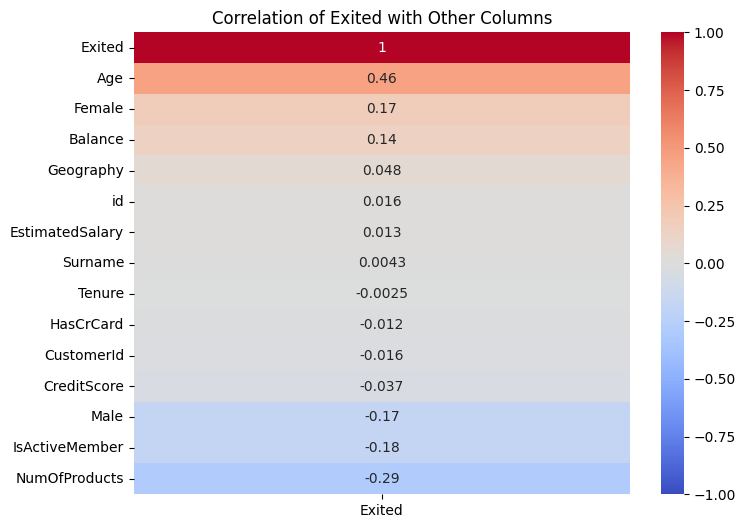

In [ ]:
#Finding co-relation using heatmap
corr_matrix = df.corr()

ten_year_chd_corr = corr_matrix[['Exited']].sort_values(by='Exited', ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ten_year_chd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Exited with Other Columns')
plt.show()

<Axes: ylabel='Age'>

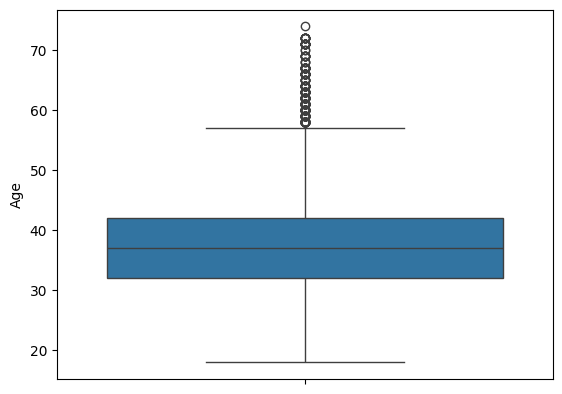

In [ ]:
#boxplot for finding outlier
sns.boxplot(df['Age'])

<Axes: ylabel='Balance'>

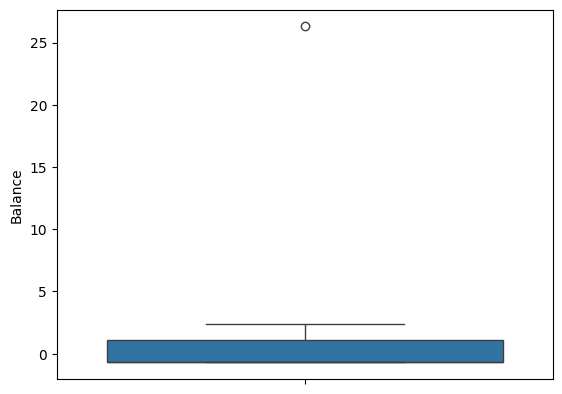

In [ ]:
sns.boxplot(df['Balance'])

<Axes: ylabel='EstimatedSalary'>

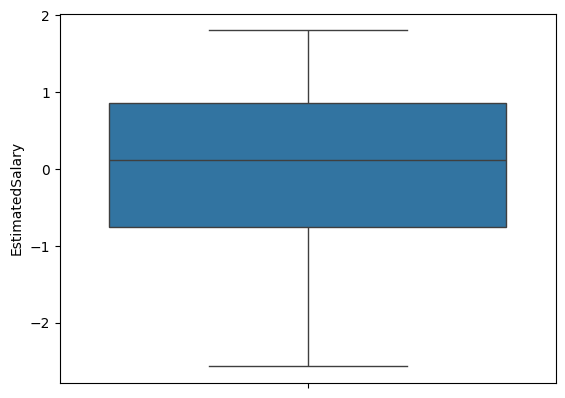

In [ ]:
sns.boxplot(df['EstimatedSalary'])

In [ ]:
#capping the outlier using IQR method
q1_age =df['Age'].quantile(0.25)
q3_age =df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

In [ ]:
df.shape

(13501, 15)

In [ ]:
df.loc[ df['Age'] > upper_bound_age, 'Age'] = upper_bound_age
df.loc[ df['Age'] < lower_bound_age, 'Age'] = lower_bound_age

<Axes: ylabel='Age'>

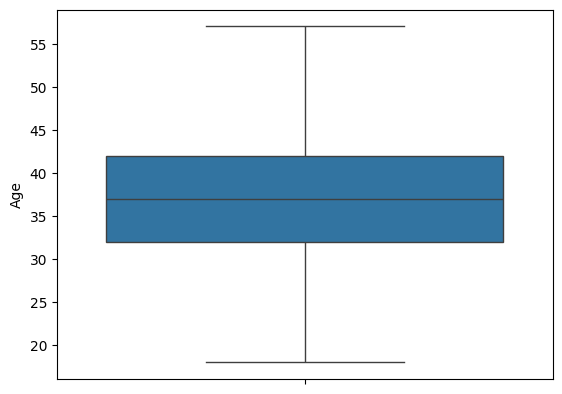

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["CustomerId"]=le.fit_transform(df["CustomerId"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  int64  
 2   Surname          13501 non-null  int64  
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  int64  
 5   Age              13501 non-null  int64  
 6   Tenure           13501 non-null  int64  
 7   Balance          13501 non-null  float64
 8   NumOfProducts    13501 non-null  int64  
 9   HasCrCard        13501 non-null  int64  
 10  IsActiveMember   13501 non-null  int64  
 11  EstimatedSalary  13501 non-null  float64
 12  Exited           13501 non-null  int64  
 13  Female           13501 non-null  int64  
 14  Male             13501 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 1.5 MB


In [ ]:
df

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13496,13496,2646,160,589,2,35,4,0.949390,1,1,0,0.574522,0,0,1
13497,13497,5599,687,744,2,34,8,-0.703981,1,1,1,-2.327678,0,0,1
13498,13498,3462,291,745,0,36,9,-0.703981,1,0,1,-1.170329,1,1,0
13499,13499,3724,297,659,2,37,9,1.405713,1,0,1,1.663974,0,0,1


In [ ]:
#splitting dependent and independent variables
x=pd.DataFrame(df.drop(['Exited'], axis=1))
y=pd.DataFrame(df['Exited'])

In [ ]:
# spliting the data into training and testing data
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
#using decision tree classifier for training the model
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
#predicting the values of y using X_test
y_pred=dt.predict(X_test)

In [ ]:
#checking the accuracy score by comparaing with y_test and y_pred
accuracy_score(y_test,y_pred)

0.8381956912028725

In [ ]:
# plotting the decision tree with the max depth of 5
from sklearn.tree import plot_tree,export_text
import matplotlib.pyplot as plt

[Text(0.5418632075471698, 0.9285714285714286, 'x[5] <= 42.5\ngini = 0.325\nsamples = 9045\nvalue = [7200, 1845]'),
 Text(0.2865566037735849, 0.7857142857142857, 'x[8] <= 1.5\ngini = 0.171\nsamples = 6926\nvalue = [6273, 653]'),
 Text(0.1509433962264151, 0.6428571428571429, 'x[5] <= 38.5\ngini = 0.324\nsamples = 2590\nvalue = [2063, 527]'),
 Text(0.07547169811320754, 0.5, 'x[13] <= 0.5\ngini = 0.248\nsamples = 1949\nvalue = [1666, 283]'),
 Text(0.03773584905660377, 0.35714285714285715, 'x[10] <= 0.5\ngini = 0.347\nsamples = 792\nvalue = [615, 177]'),
 Text(0.018867924528301886, 0.21428571428571427, 'x[5] <= 30.5\ngini = 0.428\nsamples = 394\nvalue = [272, 122]'),
 Text(0.009433962264150943, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.02830188679245283, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.05660377358490566, 0.21428571428571427, 'x[5] <= 32.5\ngini = 0.238\nsamples = 398\nvalue = [343, 55]'),
 Text(0.04716981132075472, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.066037735

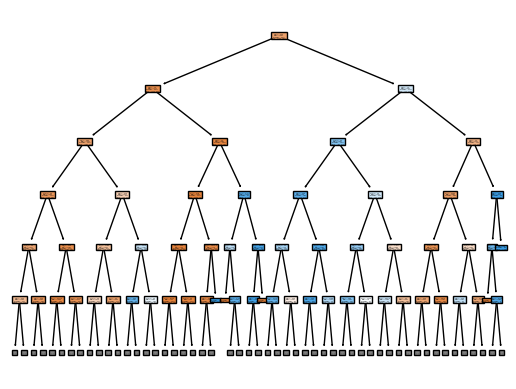

In [ ]:
plot_tree(dt,filled=True,max_depth=5)

In [ ]:
#checking the maximum depth of th tree
dt.tree_.max_depth

22

In [ ]:
#checking for accuracy with various depth levels
for max_d in range(1,23):
    dt=DecisionTreeClassifier(max_depth=max_d,random_state=2)
    dt.fit(X_train,y_train)
    print('The Training Accuracy for max_depth {} is:'.format(max_d), dt.score(X_train, y_train))
    print('The testing Accuracy for max_depth {} is:'.format(max_d), dt.score(X_test,y_test))
    print("\n")

The Training Accuracy for max_depth 1 is: 0.8253178551686015
The testing Accuracy for max_depth 1 is: 0.8319120287253142


The Training Accuracy for max_depth 2 is: 0.8644555002763958
The testing Accuracy for max_depth 2 is: 0.8738779174147218


The Training Accuracy for max_depth 3 is: 0.8798231066887783
The testing Accuracy for max_depth 3 is: 0.8850987432675045


The Training Accuracy for max_depth 4 is: 0.886456605859591
The testing Accuracy for max_depth 4 is: 0.8873429084380611


The Training Accuracy for max_depth 5 is: 0.8907683803206191
The testing Accuracy for max_depth 5 is: 0.8864452423698385


The Training Accuracy for max_depth 6 is: 0.8983969043670537
The testing Accuracy for max_depth 6 is: 0.8877917414721723


The Training Accuracy for max_depth 7 is: 0.9065782200110558
The testing Accuracy for max_depth 7 is: 0.8855475763016158


The Training Accuracy for max_depth 8 is: 0.9177446102819237
The testing Accuracy for max_depth 8 is: 0.8785906642728905


The Training Accu

In [ ]:
# comparing the decision tree model with logistic regression
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(max_iter=1000, random_state=1)
log.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
y_pred_new = log.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_new)

0.8700628366247756

In [ ]:
#checking the accuracy of decision tree by tuninig the parameter
dt1=DecisionTreeClassifier(criterion="gini")
dt1.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred1=dt1.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred1)

0.8413375224416517

In [ ]:
#Hyperparameter tuning
dt2=DecisionTreeClassifier(criterion="entropy", max_depth=4)
dt2.fit(X_train,y_train)
y_pred2=dt2.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred2)

0.8882405745062837

**Conclusion:**

* Based on the above inference we have trained the model using Decisiontree
* Upon checking we could see that initially the dataset have higher accuracy with logistic regression in compared to Decision Tree

* Later on Hyper parameter tuning we could achieve more accuracy by tuning the depth level to 4 and criterion="entropy" with the accuracy of 88.8 %

* This model accuracy can be further improved using hyper-parameter tuning by trail-error method  